### Entraînement d'un modèle d'apprentissage automatique simple

Cet exemple démontre un modèle de régression linéaire basique :
1.  **Générer des données synthétiques**: Créer un ensemble de données simple avec une relation linéaire et du bruit.
2.  **Entraîner un modèle de régression linéaire**: Utiliser `scikit-learn` pour ajuster un modèle linéaire aux données.
3.  **Visualiser les résultats**: Représenter graphiquement les données originales et les prédictions du modèle.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# 1. Générer des données synthétiques
np.random.seed(42)
X = 2 * np.random.rand(100, 1) # 100 échantillons, 1 caractéristique
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3x + bruit

print(f"Forme de X: {X.shape}")
print(f"Forme de y: {y.shape}")

Forme de X: (100, 1)
Forme de y: (100, 1)


Visualisons d'abord les données générées pour comprendre leur distribution.

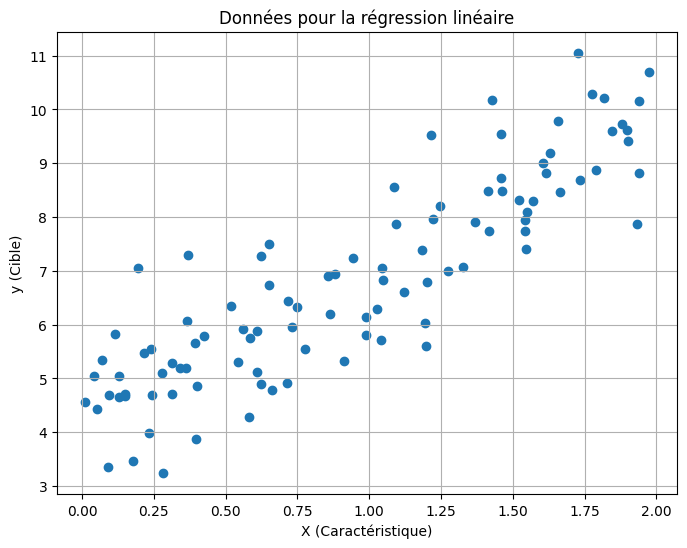

In [3]:
# Visualiser les données générées
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=1)
plt.xlabel("X (Caractéristique)")
plt.ylabel("y (Cible)")
plt.title("Données pour la régression linéaire")
plt.grid(True)
plt.show()

Maintenant, nous allons diviser les données en ensembles d'entraînement et de test, puis entraîner un modèle de régression linéaire.

In [4]:
# 2. Diviser les données en ensembles d'entraînement et de test
X_entrain, X_test, y_entrain, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Créer et entraîner un modèle de régression linéaire
modele = LinearRegression()
modele.fit(X_entrain, y_entrain)

print(f"Coefficient (pente) du modèle: {modele.coef_[0][0]:.1f}")
print(f"Ordonnée à l'origine du modèle: {modele.intercept_[0]:.1f}")

Coefficient (pente) du modèle: 2.8
Ordonnée à l'origine du modèle: 4.1


Enfin, nous allons faire des prédictions sur l'ensemble de test et visualiser la qualité de l'ajustement de notre modèle aux données.

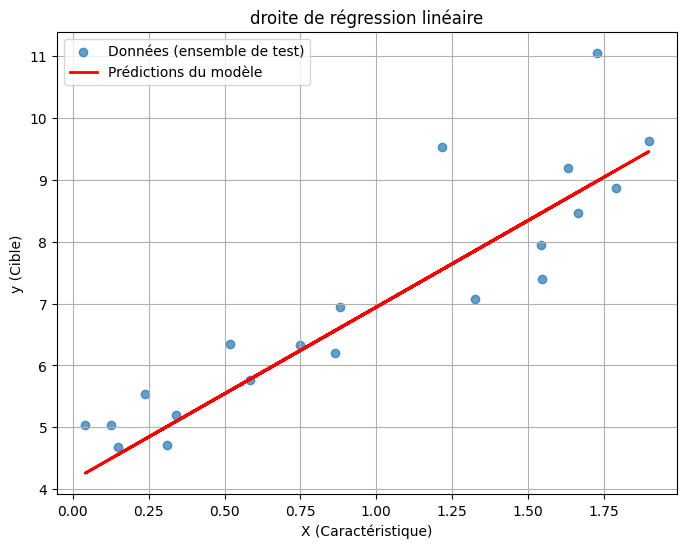

In [5]:
# 4. Faire des prédictions sur l'ensemble de test
y_pred = modele.predict(X_test)

# 5. Visualiser la performance du modèle
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, alpha=0.7, label="Données (ensemble de test)")
plt.plot(X_test, y_pred, color='red', linewidth=2, label="Prédictions du modèle")
plt.xlabel("X (Caractéristique)")
plt.ylabel("y (Cible)")
plt.title("droite de régression linéaire")
plt.legend()
plt.grid(True)
plt.show()

# Évaluer le modèle (facultatif, mais bonne pratique)
# from sklearn.metrics import mean_squared_error, r2_score
# mse = mean_squared_error(y_test, y_pred)
# r = r_score(y_test, y_pred)

# print(f"\nErreur Quadratique Moyenne sur l'ensemble de test: {mse:.2f}")
# print(f"R-carré sur l'ensemble de test: {r:.2f}")

---

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# Prétraitement pour les différentes colonnes
preprocessor = ColumnTransformer(
    transformers=[
        ('text_feature', CountVectorizer(), 'email'),
        ('numerical_features', StandardScaler(), ['heure_envoi', 'nombre_fautes', 'longueur_email'])
    ],
    remainder='passthrough' # Laisse les autres colonnes telles quelles (utile si d'autres colonnes existent)
)

# Construction du pipeline avec le ColumnTransformer
spam_detector_pipeline_multi = make_pipeline(preprocessor, LogisticRegression(solver='liblinear', random_state=42))

print("Nouveau Pipeline de détection de spam avec ColumnTransformer créé:")
print(spam_detector_pipeline_multi)

Ma base de donné fictive

In [6]:
# @title
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report# Mise à jour de la création du jeu de données pour inclure de nouvelles variables

# Suppression de la cellule précédente qui créait le DataFrame `df`
# pour éviter les doublons ou les erreurs de définition.

data_plu = {
    'email': [
        "Félicitations ! Vous avez gagné un prix incroyable ! Cliquez ici.", # Spam
        "Bonjour, voici les notes de la réunion de ce matin.", # Non-Spam
        "URGENT: Votre compte bancaire a été compromis. Veuillez vous connecter.", # Spam
        "Newsletter mensuelle de votre site préféré.", # Non-Spam
        "VOTRE CADEAU GRATUIT VOUS ATTEND MAINTENANT !", # Spam
        "Rappel: Entretien d'embauche demain à 10h.", # Non-Spam
        "Gagnez de l'argent facile depuis chez vous !", # Spam
        "Confirmation de commande #123456.", # Non-Spam
        "Opportunité d'investissement exclusive et limitée.", # Spam
        "Facture de ce mois-ci disponible en ligne." # Non-Spam
    ],
    'label': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    'heure_envoi': [2, 9, 3, 10, 1, 11, 4, 14, 5, 13], # Heure 'typique' d'envoi (spam souvent très tôt/tard)
    'nombre_fautes': [3, 0, 2, 0, 4, 0, 1, 0, 3, 0], # Nombre simulé de fautes d'orthographe
    'lien':[1, 0, 1, 1, 0, 1, 0, 0, 1, 0]
}

df_plus = pd.DataFrame(data_plu)

# Ajout d'une caractéristique basée sur la longueur de l'email
df_plus['longueur_email'] = df_plus['email'].apply(len)

print("Nouveau jeu de données enrichi créé:")

# Séparer les caractéristiques (X) et la cible (y)
X_plus = df_plus[['email', 'heure_envoi', 'nombre_fautes', 'longueur_email']]
y_plus = df_plus['label']

print("\nDivision du nouveau jeu de données en ensembles d'entraînement et de test...")
X_train_plus, X_test_plus, y_train_plus, y_test_plus = train_test_split(X_plus, y_plus, test_size=0.3, random_state=42)
print(f"Taille de l'ensemble d'entraînement: {len(X_train_plus)} e-mails")
print(f"Taille de l'ensemble de test: {len(X_test_plus)} e-mails")

Nouveau jeu de données enrichi créé:

Division du nouveau jeu de données en ensembles d'entraînement et de test...
Taille de l'ensemble d'entraînement: 7 e-mails
Taille de l'ensemble de test: 3 e-mails


le preprocessor

In [7]:
# @title
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# Prétraitement pour les différentes colonnes
preprocessor = ColumnTransformer(
    transformers=[
        ('text_feature', CountVectorizer(), 'email'),
        ('numerical_features', StandardScaler(), ['heure_envoi', 'nombre_fautes', 'longueur_email'])
    ],
    remainder='passthrough' # Laisse les autres colonnes telles quelles (utile si d'autres colonnes existent)
)

In [8]:
# resauux de neurones
from sklearn.neural_network import MLPClassifier
model_n = make_pipeline(preprocessor, MLPClassifier(hidden_layer_sizes=(200, 100, 50, 25), max_iter=1000, random_state=42))

la foret d'arbre

In [9]:
# @title
# Construction du pipeline avec le ColumnTransformer
spam_detector_pipeline_multi = make_pipeline(preprocessor, LogisticRegression(solver='liblinear', random_state=42))

print("Nouveau Pipeline de détection de spam avec ColumnTransformer créé")

Nouveau Pipeline de détection de spam avec ColumnTransformer créé


l'entrainement du model

In [10]:
# @title
# 3. Entraîner le nouveau pipeline sur les données d'entraînement enrichies
print("\nEntraînement du modèle de détection de spam avec plus de caractéristiques...")
model_n.fit(X_train_plus, y_train_plus)
print("Entraînement terminé.")

# 4. Faire des prédictions sur l'ensemble de test enrichi
y_pred_plus = model_n.predict(X_test_plus)

# 5. Évaluer les performances du nouveau modèle
print("\nÉvaluation du nouveau modèle (avec plus de caractéristiques):")
print(f"Précision (Accuracy): {accuracy_score(y_test_plus, y_pred_plus):.2f}")
print("\nRapport de Classification (avec plus de caractéristiques):\n")
print(classification_report(y_test_plus, y_pred_plus, target_names=['Non-Spam', 'Spam']))


Entraînement du modèle de détection de spam avec plus de caractéristiques...
Entraînement terminé.

Évaluation du nouveau modèle (avec plus de caractéristiques):
Précision (Accuracy): 1.00

Rapport de Classification (avec plus de caractéristiques):

              precision    recall  f1-score   support

    Non-Spam       1.00      1.00      1.00         2
        Spam       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [11]:
import pandas as pd

# 6. Tester le nouveau modèle avec de nouveaux e-mails (avec des caractéristiques enrichies)
# Pour tester, nous devons créer un DataFrame pour les nouveaux e-mails avec toutes les caractéristiques.

nouveaux_emails_plus = pd.DataFrame({
    'email': [
        "Retrouvaille entre amies",
        "URGENT:Gagnez votre cadeau maintenant",
        "URGENT:Récupérer votre cadeau aujourd'hui en magazin",
        "Réunion projet Unit02",
        "Le ciel est bleu les oiseaux chantent"
    ],
    'heure_envoi': [21, 14, 13, 3, 12],
    'nombre_fautes': [7, 0, 1, 0, 1],
    'lien':[0, 1, 0, 1, 0]
})
# Ajout de la longueur de l'email pour les nouveaux emails
nouveaux_emails_plus['longueur_email'] = nouveaux_emails_plus['email'].apply(len)

predictions_nouvelles_plus = model_n.predict(nouveaux_emails_plus)
predictions_proba_plus = model_n.predict_proba(nouveaux_emails_plus)

# Ajouter le statut de prédiction et les probabilités au DataFrame
nouveaux_emails_plus['Statut'] = ['SPAM' if p == 1 else 'Non-Spam' for p in predictions_nouvelles_plus]
nouveaux_emails_plus['Probabilité Non-Spam'] = [p[0] for p in predictions_proba_plus]
nouveaux_emails_plus['Probabilité SPAM'] = [p[1] for p in predictions_proba_plus]

print("\nPrédictions et Probabilités pour les nouveaux e-mails :")
for a, b, c, d in zip(nouveaux_emails_plus['email'], nouveaux_emails_plus['Statut'], nouveaux_emails_plus['Probabilité Non-Spam'], nouveaux_emails_plus['Probabilité SPAM']):
  print("\nl'email :", '"', a, '"', "est un :", b)
  print("Probabilité Non-Spam :", c)
  print("Probabilité SPAM :", d)


Prédictions et Probabilités pour les nouveaux e-mails :

l'email : " Retrouvaille entre amies " est un : Non-Spam
Probabilité Non-Spam : 0.5140302070746167
Probabilité SPAM : 0.48596979292538334

l'email : " URGENT:Gagnez votre cadeau maintenant " est un : Non-Spam
Probabilité Non-Spam : 0.946909983867744
Probabilité SPAM : 0.0530900161322559

l'email : " URGENT:Récupérer votre cadeau aujourd'hui en magazin " est un : Non-Spam
Probabilité Non-Spam : 0.8641641716419113
Probabilité SPAM : 0.13583582835808866

l'email : " Réunion projet Unit02 " est un : Non-Spam
Probabilité Non-Spam : 0.5008417000055159
Probabilité SPAM : 0.49915829999448413

l'email : " Le ciel est bleu les oiseaux chantent " est un : Non-Spam
Probabilité Non-Spam : 0.9531226953658147
Probabilité SPAM : 0.046877304634185296


In [12]:
# @title
# 3. Entraîner le nouveau pipeline sur les données d'entraînement enrichies
print("\nEntraînement du modèle de détection de spam avec plus de caractéristiques...")
spam_detector_pipeline_multi.fit(X_train_plus, y_train_plus)
print("Entraînement terminé.")

# 4. Faire des prédictions sur l'ensemble de test enrichi
y_pred_plus = spam_detector_pipeline_multi.predict(X_test_plus)

# 5. Évaluer les performances du nouveau modèle
print("\nÉvaluation du nouveau modèle (avec plus de caractéristiques):")
print(f"Précision (Accuracy): {accuracy_score(y_test_plus, y_pred_plus):.2f}")
print("\nRapport de Classification (avec plus de caractéristiques):\n")
print(classification_report(y_test_plus, y_pred_plus, target_names=['Non-Spam', 'Spam']))


Entraînement du modèle de détection de spam avec plus de caractéristiques...
Entraînement terminé.

Évaluation du nouveau modèle (avec plus de caractéristiques):
Précision (Accuracy): 1.00

Rapport de Classification (avec plus de caractéristiques):

              precision    recall  f1-score   support

    Non-Spam       1.00      1.00      1.00         2
        Spam       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [13]:
import pandas as pd

# 6. Tester le nouveau modèle avec de nouveaux e-mails (avec des caractéristiques enrichies)
# Pour tester, nous devons créer un DataFrame pour les nouveaux e-mails avec toutes les caractéristiques.

nouveaux_emails_plus = pd.DataFrame({
    'email': [
        "Retrouvaille entre amies",
        "URGENT:Gagnez votre cadeau maintenant",
        "URGENT:Récupérer votre cadeau aujourd'hui en magazin",
        "Réunion projet Unit02",
        "Le ciel est bleu les oiseaux chantent"
    ],
    'heure_envoi': [21, 14, 13, 3, 12],
    'nombre_fautes': [7, 0, 1, 0, 1],
    'lien':[0, 1, 0, 1, 0]
})
# Ajout de la longueur de l'email pour les nouveaux emails
nouveaux_emails_plus['longueur_email'] = nouveaux_emails_plus['email'].apply(len)

predictions_nouvelles_plus = spam_detector_pipeline_multi.predict(nouveaux_emails_plus)
predictions_proba_plus = spam_detector_pipeline_multi.predict_proba(nouveaux_emails_plus)

# Ajouter le statut de prédiction et les probabilités au DataFrame
nouveaux_emails_plus['Statut'] = ['SPAM' if p == 1 else 'Non-Spam' for p in predictions_nouvelles_plus]
nouveaux_emails_plus['Probabilité Non-Spam'] = [p[0] for p in predictions_proba_plus]
nouveaux_emails_plus['Probabilité SPAM'] = [p[1] for p in predictions_proba_plus]

print("\nPrédictions et Probabilités pour les nouveaux e-mails :")
for a, b, c, d in zip(nouveaux_emails_plus['email'], nouveaux_emails_plus['Statut'], nouveaux_emails_plus['Probabilité Non-Spam'], nouveaux_emails_plus['Probabilité SPAM']):
  print("\nl'email :", '"', a, '"', "est un :", b)
  print("Probabilité Non-Spam :", c)
  print("Probabilité SPAM :", d)


Prédictions et Probabilités pour les nouveaux e-mails :

l'email : " Retrouvaille entre amies " est un : Non-Spam
Probabilité Non-Spam : 0.6513041118993443
Probabilité SPAM : 0.3486958881006556

l'email : " URGENT:Gagnez votre cadeau maintenant " est un : Non-Spam
Probabilité Non-Spam : 0.7777969990567867
Probabilité SPAM : 0.22220300094321332

l'email : " URGENT:Récupérer votre cadeau aujourd'hui en magazin " est un : Non-Spam
Probabilité Non-Spam : 0.6730110049053383
Probabilité SPAM : 0.3269889950946617

l'email : " Réunion projet Unit02 " est un : Non-Spam
Probabilité Non-Spam : 0.6711817031497775
Probabilité SPAM : 0.3288182968502225

l'email : " Le ciel est bleu les oiseaux chantent " est un : Non-Spam
Probabilité Non-Spam : 0.7515063875071739
Probabilité SPAM : 0.2484936124928261


## Explication de `ColumnTransformer`

Vous avez demandé si nous utilisions `ColumnTransformer()`. C'est un composant très puissant de `scikit-learn` qui est utilisé lorsque votre jeu de données contient **différents types de caractéristiques** (par exemple, du texte et des nombres) qui nécessitent **des traitements différents**.

Imaginez un tableau de données (DataFrame) avec plusieurs colonnes :
*   Une colonne de texte (`email`)
*   Des colonnes numériques (`heure_envoi`, `nombre_fautes`)
*   Des colonnes catégorielles (par exemple, `jour_de_la_semaine`)

Chaque type de colonne doit être transformé différemment :
*   Le texte doit être vectorisé (comme avec `CountVectorizer` ou `TfidfVectorizer`).
*   Les nombres pourraient nécessiter une mise à l'échelle (`StandardScaler`, `MinMaxScaler`).
*   Les catégories pourraient être encodées (`OneHotEncoder`).

`ColumnTransformer` permet de spécifier ces transformations **en parallèle** pour différentes colonnes et de combiner les résultats. Sans `ColumnTransformer`, vous devriez gérer chaque type de colonne séparément, ce qui serait plus complexe et sujet aux erreurs.

### Structure de base d'un `ColumnTransformer`:

```python
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('text_pipeline', CountVectorizer(), 'email'),  # Applique CountVectorizer à la colonne 'email'
        ('num_pipeline', StandardScaler(), ['heure_envoi', 'nombre_fautes']), # Applique StandardScaler aux colonnes numériques
        ('cat_pipeline', OneHotEncoder(), ['jour_de_la_semaine']) # Applique OneHotEncoder aux colonnes catégorielles
    ])
```

Le `ColumnTransformer` peut ensuite être inclus dans un `Pipeline` général pour gérer tout le flux de travail de pré-traitement et de modélisation de manière unifiée. Nous l'utiliserons dans l'étape suivante pour intégrer les nouvelles variables à notre modèle !
